In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

In [3]:
telemetry = pd.read_csv('PdM_telemetry.csv')
errors = pd.read_csv('PdM_errors.csv')
maint = pd.read_csv('PdM_maint.csv')
failures = pd.read_csv('PdM_failures.csv')
machines = pd.read_csv('PdM_machines.csv')

In [38]:
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [4]:
print(telemetry.dtypes)
print(failures.dtypes)
print(maint.dtypes)
print(machines.dtypes)
print(errors.dtypes)

datetime      object
machineID      int64
volt         float64
rotate       float64
pressure     float64
vibration    float64
dtype: object
datetime     object
machineID     int64
failure      object
dtype: object
datetime     object
machineID     int64
comp         object
dtype: object
machineID     int64
model        object
age           int64
dtype: object
datetime     object
machineID     int64
errorID      object
dtype: object


In [5]:
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [6]:
errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [7]:
maint.head()

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


In [8]:
failures.head()

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


In [9]:
telemetry['datetime'] = pd.to_datetime(telemetry['datetime'])
telemetry_2015 = telemetry[telemetry['datetime'].dt.year == 2015]

In [10]:
telemetry['datetime'] = pd.to_datetime(
    telemetry['datetime'], format="%Y-%m-%d %H:%M:%S")

print("Total number of telemetry records: %d" % len(telemetry.index))

telemetry.describe()

Total number of telemetry records: 876100


,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 18:00:00,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


In [11]:
machine1 = telemetry_2015[telemetry_2015['machineID'] == 1]
start_date = "2015-01-01"
end_date = "2015-01-15"
machine1_15days = machine1[
    (machine1['datetime'] >= start_date) & (machine1['datetime'] < end_date)
]

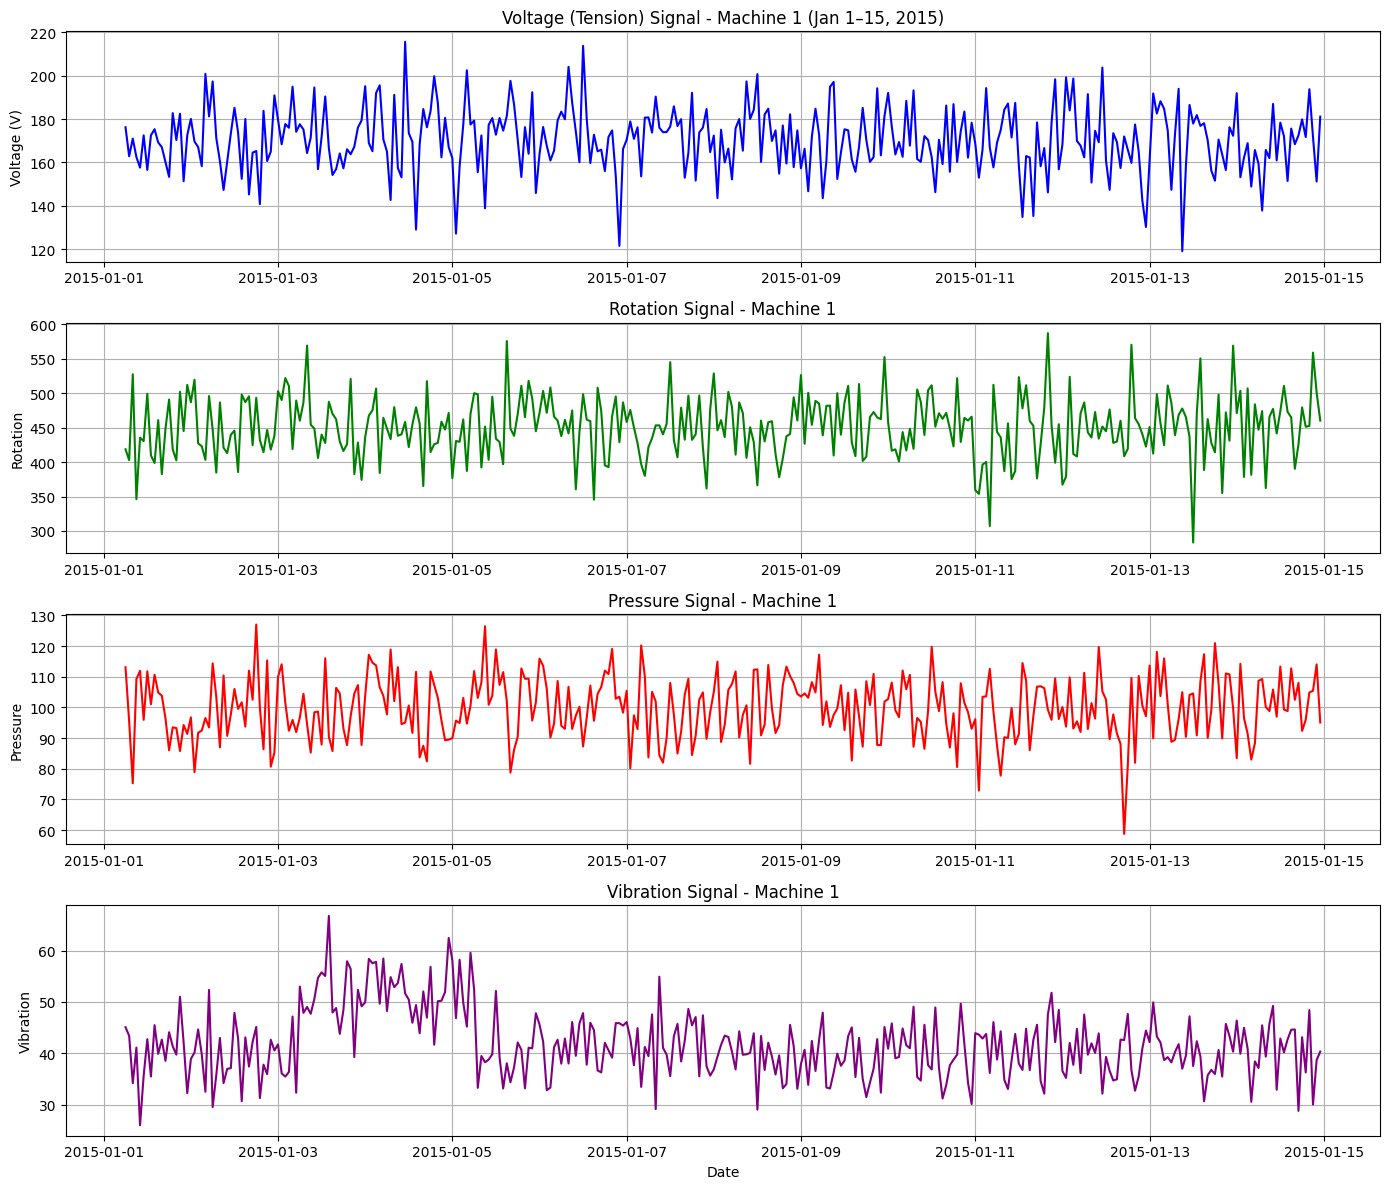

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 12))

# Figure 2a - Voltage (Tension)
plt.subplot(4,1,1)
plt.plot(machine1_15days['datetime'], machine1_15days['volt'], color='blue')
plt.title("Voltage (Tension) Signal - Machine 1 (Jan 1–15, 2015)")
plt.ylabel("Voltage (V)")
plt.grid(True)

# Figure 2b - Rotation
plt.subplot(4,1,2)
plt.plot(machine1_15days['datetime'], machine1_15days['rotate'], color='green')
plt.title("Rotation Signal - Machine 1")
plt.ylabel("Rotation")
plt.grid(True)

# Figure 2c - Pressure
plt.subplot(4,1,3)
plt.plot(machine1_15days['datetime'], machine1_15days['pressure'], color='red')
plt.title("Pressure Signal - Machine 1")
plt.ylabel("Pressure")
plt.grid(True)

# Figure 2d - Vibration
plt.subplot(4,1,4)
plt.plot(machine1_15days['datetime'], machine1_15days['vibration'], color='purple')
plt.title("Vibration Signal - Machine 1")
plt.ylabel("Vibration")
plt.xlabel("Date")
plt.grid(True)

plt.tight_layout()
plt.show()

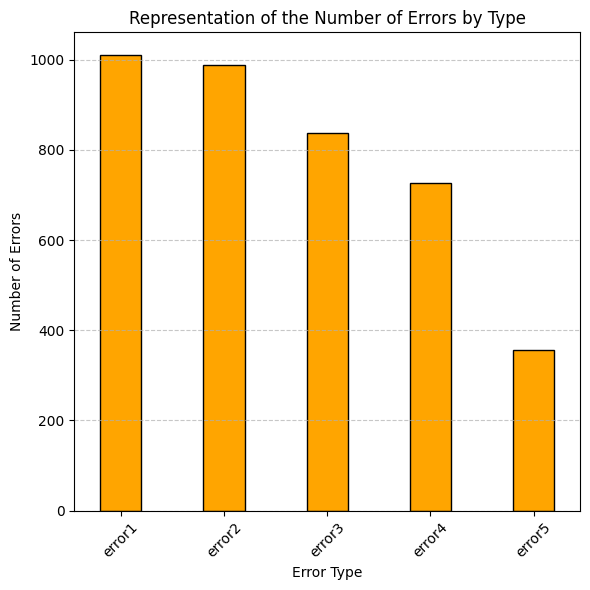

In [13]:
error_counts = errors['errorID'].value_counts()

plt.figure(figsize=(6,6))
error_counts.plot(kind='bar', color='orange', edgecolor='black', width=0.4)

plt.title("Representation of the Number of Errors by Type")
plt.xlabel("Error Type")
plt.ylabel("Number of Errors")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

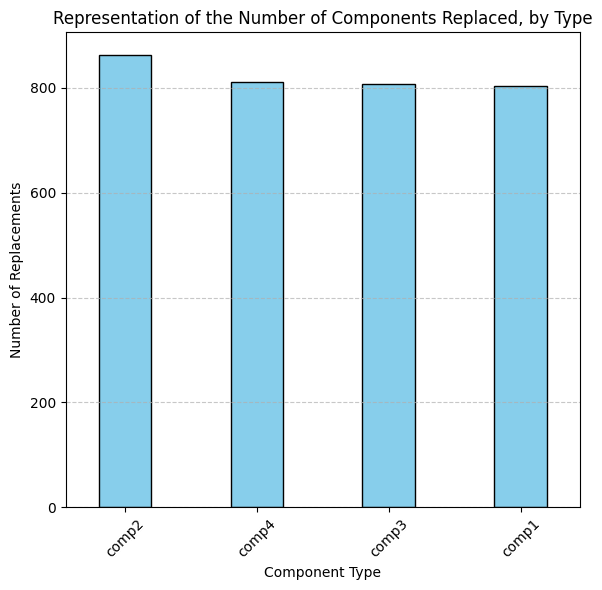

In [14]:
comp_counts = maint['comp'].value_counts()

plt.figure(figsize=(6,6))
comp_counts.plot(kind='bar', color='skyblue', edgecolor='black', width=0.4)

plt.title("Representation of the Number of Components Replaced, by Type")
plt.xlabel("Component Type")
plt.ylabel("Number of Replacements")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

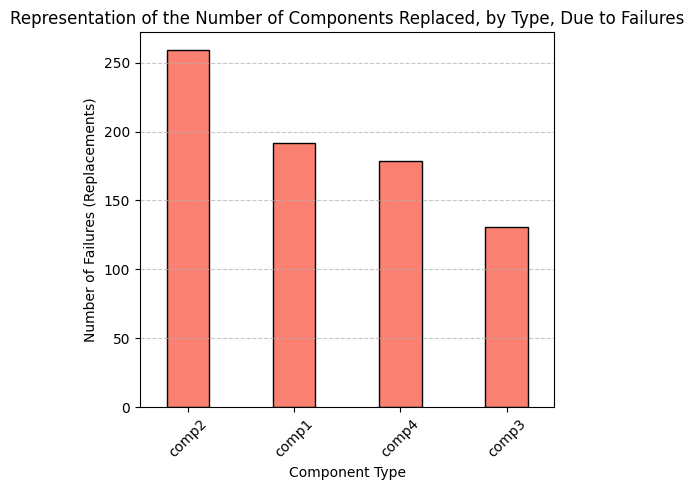

In [15]:
failure_counts = failures['failure'].value_counts()


plt.figure(figsize=(5,5))
failure_counts.plot(kind='bar', color='salmon', edgecolor='black', width=0.4)

plt.title("Representation of the Number of Components Replaced, by Type, Due to Failures")
plt.xlabel("Component Type")
plt.ylabel("Number of Failures (Replacements)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [16]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=machines.loc[machines['model'] == 'model1', 'age'], name='model1'))
fig.add_trace(go.Histogram(
    x=machines.loc[machines['model'] == 'model2', 'age'], name='model2'))
fig.add_trace(go.Histogram(
    x=machines.loc[machines['model'] == 'model3', 'age'], name='model3'))
fig.add_trace(go.Histogram(
    x=machines.loc[machines['model'] == 'model4', 'age'], name='model4',))
fig.update_layout(xaxis_title='Age', yaxis_title='Count', template='plotly_white')
fig.update_layout(barmode='stack', title='Machine Age Distribution')
fig.show()

In [17]:
# 3-hour mean features
temp = []
fields = ['volt', 'rotate', 'pressure', 'vibration']
for col in fields:
    temp.append(pd.pivot_table(telemetry,
                               index='datetime',
                               columns='machineID',
                               values=col).resample('3h', closed='left', label='right').mean().unstack())
telemetry_mean_3h = pd.concat(temp, axis=1)
telemetry_mean_3h.columns = [i + 'mean_3h' for i in fields]
telemetry_mean_3h.reset_index(inplace=True)

# 3-hour standard deviation features
temp = []
for col in fields:
    temp.append(pd.pivot_table(telemetry,
                               index='datetime',
                               columns='machineID',
                               values=col).resample('3h', closed='left', label='right').std().unstack())
telemetry_sd_3h = pd.concat(temp, axis=1)
telemetry_sd_3h.columns = [i + 'sd_3h' for i in fields]
telemetry_sd_3h.reset_index(inplace=True)

In [18]:
# 24-hour rolling mean features
temp = []
for col in fields:
    temp.append(pd.pivot_table(telemetry,
                               index='datetime',
                               columns='machineID',
                               values=col).resample('3h', closed='left', label='right').first().unstack().rolling(window=24, center=False).mean())
telemetry_mean_24h = pd.concat(temp, axis=1)
telemetry_mean_24h.columns = [i + 'mean_24h' for i in fields]
telemetry_mean_24h.reset_index(inplace=True)
telemetry_mean_24h = telemetry_mean_24h.loc[-telemetry_mean_24h['voltmean_24h'].isnull()]

# 24-hour rolling standard deviation features
temp = []
for col in fields:
    temp.append(pd.pivot_table(telemetry,
                               index='datetime',
                               columns='machineID',
                               values=col).resample('3h', closed='left', label='right').first().unstack().rolling(window=24, center=False).std())
telemetry_sd_24h = pd.concat(temp, axis=1)
telemetry_sd_24h.columns = [i + 'sd_24h' for i in fields]
telemetry_sd_24h.reset_index(inplace=True)
telemetry_sd_24h = telemetry_sd_24h.loc[-telemetry_sd_24h['voltsd_24h'].isnull()]


In [19]:
# Combine telemetry features
telemetry_feat = pd.concat([telemetry_mean_3h,
                            telemetry_sd_3h.iloc[:, 2:6],
                            telemetry_mean_24h.iloc[:, 2:6],
                            telemetry_sd_24h.iloc[:, 2:6]], axis=1).dropna()
telemetry_feat.describe()

,machineID,datetime,voltmean_3h,rotatemean_3h,pressuremean_3h,vibrationmean_3h,voltsd_3h,rotatesd_3h,pressuresd_3h,vibrationsd_3h,voltmean_24h,rotatemean_24h,pressuremean_24h,vibrationmean_24h,voltsd_24h,rotatesd_24h,pressuresd_24h,vibrationsd_24h
count,291977.000000,291977,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000,291977.000000
mean,50.503899,2015-07-02 19:50:32.314188800,170.777344,446.605536,100.858665,40.384696,13.299177,44.456698,8.885976,4.441105,170.738342,446.622451,100.871860,40.382356,15.055923,50.680485,10.330242,5.103534
min,1.000000,2015-01-01 09:00:00,125.532506,211.811184,72.118639,26.569635,0.025509,0.078991,0.027417,0.015278,156.713608,310.118604,91.162625,35.800869,6.178154,18.363177,4.275651,2.108104
25%,26.000000,2015-04-02 15:00:00,164.449518,427.559989,96.238713,38.147732,8.027807,26.903727,5.370694,2.684653,168.100594,440.859663,98.730139,39.379127,13.409911,44.992826,8.984156,4.488631
50%,51.000000,2015-07-02 21:00:00,170.434250,448.382424,100.234309,40.145805,12.495649,41.794255,8.346061,4.173937,170.285725,448.772454,100.195972,40.107229,14.942428,50.156537,10.009680,5.008386
75%,76.000000,2015-10-02 03:00:00,176.612207,468.448273,104.406729,42.227512,17.688547,59.105539,11.790367,5.899868,172.609273,456.129192,101.780484,40.908734,16.556760,55.657662,11.199380,5.589524
max,100.000000,2016-01-01 06:00:00,241.420717,586.682904,162.309656,69.311324,58.444332,179.903039,35.659369,18.305595,206.333895,491.081522,138.291979,55.266429,30.806053,117.198342,30.665847,12.757609
std,28.863913,NaN,9.501061,33.130486,7.414592,3.478391,6.966005,23.217195,4.656154,2.320281,4.178951,15.686284,3.983127,1.764322,2.383652,8.368899,2.129642,0.921640


In [20]:
telemetry_feat

,machineID,datetime,voltmean_3h,rotatemean_3h,pressuremean_3h,vibrationmean_3h,voltsd_3h,rotatesd_3h,pressuresd_3h,vibrationsd_3h,voltmean_24h,rotatemean_24h,pressuremean_24h,vibrationmean_24h,voltsd_24h,rotatesd_24h,pressuresd_24h,vibrationsd_24h
23,1,2015-01-04 06:00:00,186.092896,451.641253,107.989359,55.308074,13.489090,62.185045,5.118176,4.904365,171.536044,456.036706,101.652072,44.017022,13.716658,41.767447,11.754808,6.878286
24,1,2015-01-04 09:00:00,166.281848,453.787824,106.187582,51.990080,24.276228,23.621315,11.176731,3.394073,171.069056,457.285237,101.011726,44.148324,13.741098,41.038218,11.521602,6.929500
25,1,2015-01-04 12:00:00,175.412103,445.450581,100.887363,54.251534,34.918687,11.001625,10.580336,2.921501,170.859615,461.116153,101.172241,44.672216,13.915181,33.879652,11.667258,7.162152
26,1,2015-01-04 15:00:00,157.347716,451.882075,101.289380,48.602686,24.617739,28.950883,9.966729,2.356486,171.566669,457.893518,100.708151,44.993232,13.583969,33.790685,11.447426,7.244618
27,1,2015-01-04 18:00:00,176.450550,446.033068,84.521555,47.638836,8.071400,76.511343,2.636879,4.108621,171.536866,457.672110,99.826551,45.160570,13.590129,33.787875,11.919716,7.167877
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292094,100,2015-12-31 18:00:00,177.758754,458.391629,103.183160,46.846592,13.147011,75.100940,3.111700,3.576693,165.237423,438.914866,98.210559,38.435573,14.535213,53.787921,8.432559,5.186834
292095,100,2015-12-31 21:00:00,166.078945,424.431184,98.344409,30.907459,29.351231,69.348245,16.940674,3.731256,167.150652,435.983604,98.622717,37.811625,15.567171,56.137501,8.410123,5.216629
292096,100,2016-01-01 00:00:00,158.327984,504.056262,108.055441,40.109705,9.605817,78.036116,9.154932,3.379639,167.039345,441.478463,98.863161,37.660150,15.659078,60.780994,8.335349,5.163375
292097,100,2016-01-01 03:00:00,170.306956,438.653616,102.346227,47.481232,8.457322,43.021553,0.785721,3.198928,167.541122,437.475072,99.025311,38.053762,15.505467,57.383731,8.381265,5.525251


In [21]:
# Error count features
error_count = pd.get_dummies(errors.set_index('datetime'), columns=['errorID']).reset_index()
error_count = error_count.astype(int, errors='ignore')
error_count.columns = ['datetime', 'machineID', 'error1', 'error2', 'error3', 'error4', 'error5']
error_count['datetime'] = pd.to_datetime(error_count['datetime'])
error_count = telemetry[['datetime', 'machineID']].merge(error_count, on=['machineID', 'datetime'], how='left').fillna(0.0)

temp = []
fields = ['error%d' % i for i in range(1, 6)]
for col in fields:
    temp.append(pd.pivot_table(error_count,
                               index='datetime',
                               columns='machineID',
                               values=col).resample('3h', closed='left', label='right').first().unstack().rolling(window=24, center=False).sum())
error_count = pd.concat(temp, axis=1)
error_count.columns = [i + 'count' for i in fields]
error_count.reset_index(inplace=True)
error_count = error_count.dropna()

In [22]:
error_count

,machineID,datetime,error1count,error2count,error3count,error4count,error5count
23,1,2015-01-04 06:00:00,0.0,0.0,0.0,0.0,0.0
24,1,2015-01-04 09:00:00,0.0,0.0,0.0,0.0,1.0
25,1,2015-01-04 12:00:00,0.0,0.0,0.0,0.0,1.0
26,1,2015-01-04 15:00:00,0.0,0.0,0.0,0.0,1.0
27,1,2015-01-04 18:00:00,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
292095,100,2015-12-31 21:00:00,0.0,0.0,0.0,0.0,0.0
292096,100,2016-01-01 00:00:00,0.0,0.0,0.0,0.0,0.0
292097,100,2016-01-01 03:00:00,0.0,0.0,0.0,0.0,0.0
292098,100,2016-01-01 06:00:00,0.0,0.0,0.0,0.0,0.0


In [23]:
import numpy as np
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])
maint["datetime"] = pd.to_datetime(maint["datetime"])

# Component replacement features
comp_rep = pd.get_dummies(maint.set_index('datetime')).reset_index()
comp_rep.columns = ['datetime', 'machineID', 'comp1', 'comp2', 'comp3', 'comp4']
comp_rep = telemetry[['datetime', 'machineID']].merge(comp_rep,
                                                      on=['datetime', 'machineID'],
                                                      how='outer').fillna(0).sort_values(by=['machineID', 'datetime'])

components = ['comp1', 'comp2', 'comp3', 'comp4']
for comp in components:
    comp_rep.loc[comp_rep[comp] < 1, comp] = None
    comp_rep.loc[-comp_rep[comp].isnull(), comp] = comp_rep.loc[-comp_rep[comp].isnull(), 'datetime']
    comp_rep[comp] = comp_rep[comp].fillna(method='ffill')

comp_rep = comp_rep.loc[comp_rep['datetime'] > pd.to_datetime('2015-01-01')]

for comp in components:
    comp_rep[comp] = (comp_rep["datetime"] - pd.to_datetime(comp_rep[comp])) / np.timedelta64(1, "D")


/tmp/ipykernel_66868/734968927.py:16: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_66868/734968927.py:16: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_66868/734968927.py:16: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.

/tmp/ipykernel_66868/734968927.py:16: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_66868/734968927.py:16: FutureWa

In [24]:
# Merge all features
final_feat = telemetry_feat.merge(error_count, on=['datetime', 'machineID'], how='left')
final_feat = final_feat.merge(comp_rep, on=['datetime', 'machineID'], how='left')
final_feat = final_feat.merge(machines, on=['machineID'], how='left')

final_feat['datetime'] = pd.to_datetime(final_feat['datetime'])
failures['datetime'] = pd.to_datetime(failures['datetime'])
labeled_features = final_feat.merge(failures, on=['datetime', 'machineID'], how='left')
labeled_features = labeled_features.fillna(method='bfill', limit=7)
labeled_features = labeled_features.fillna('none')

/tmp/ipykernel_66868/2089447307.py:9: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



In [25]:
labeled_features.head()

,machineID,datetime,voltmean_3h,rotatemean_3h,pressuremean_3h,vibrationmean_3h,voltsd_3h,rotatesd_3h,pressuresd_3h,vibrationsd_3h,...,error3count,error4count,error5count,comp1,comp2,comp3,comp4,model,age,failure
0,1,2015-01-04 06:00:00,186.092896,451.641253,107.989359,55.308074,13.489090,62.185045,5.118176,4.904365,...,0.0,0.0,0.0,22.000,217.000,157.000,172.000,model3,18,none
1,1,2015-01-04 09:00:00,166.281848,453.787824,106.187582,51.990080,24.276228,23.621315,11.176731,3.394073,...,0.0,0.0,1.0,22.125,217.125,157.125,172.125,model3,18,comp4
2,1,2015-01-04 12:00:00,175.412103,445.450581,100.887363,54.251534,34.918687,11.001625,10.580336,2.921501,...,0.0,0.0,1.0,22.250,217.250,157.250,172.250,model3,18,comp4
3,1,2015-01-04 15:00:00,157.347716,451.882075,101.289380,48.602686,24.617739,28.950883,9.966729,2.356486,...,0.0,0.0,1.0,22.375,217.375,157.375,172.375,model3,18,comp4
4,1,2015-01-04 18:00:00,176.450550,446.033068,84.521555,47.638836,8.071400,76.511343,2.636879,4.108621,...,0.0,0.0,1.0,22.500,217.500,157.500,172.500,model3,18,comp4


In [26]:
# Sort data by machineID and datetime
labeled_features = labeled_features.sort_values(['machineID', 'datetime']).reset_index(drop=True)

# Create targets for each hour in the next 24 hours
# We'll create 24 different target variables: hour_1, hour_2, ..., hour_24
target_columns = []

for hour in range(1, 25):
    # Multi-class target for this specific hour
    target_col = f'target_hour_{hour}_multiclass'
    labeled_features[target_col] = 'none'
    target_columns.append(target_col)
    
    # Binary target for any failure in this hour
    binary_target_col = f'target_hour_{hour}_binary'
    labeled_features[binary_target_col] = 0
    target_columns.append(binary_target_col)
    
    print(f"Creating targets for hour {hour}...")
    
    for machine_id in labeled_features['machineID'].unique():
        machine_data = labeled_features[labeled_features['machineID'] == machine_id].copy()
        machine_indices = machine_data.index
        
        for i, idx in enumerate(machine_indices):
            # Look at the specific hour ahead (convert 3h periods to hours)
            # Since we have 3h periods, hour 1-3 = period 1, hour 4-6 = period 2, etc.
            period_ahead = (hour - 1) // 3 + 1
            hour_within_period = (hour - 1) % 3
            
            future_idx = i + period_ahead
            if future_idx < len(machine_indices):
                future_failure = labeled_features.loc[machine_indices[future_idx], 'failure']
                
                if future_failure != 'none' and future_failure in components:
                    labeled_features.loc[idx, target_col] = future_failure
                    labeled_features.loc[idx, binary_target_col] = 1


Creating targets for hour 1...
Creating targets for hour 2...
Creating targets for hour 3...
Creating targets for hour 4...
Creating targets for hour 5...
Creating targets for hour 6...
Creating targets for hour 7...
Creating targets for hour 8...
Creating targets for hour 9...
Creating targets for hour 10...
Creating targets for hour 11...
Creating targets for hour 12...
Creating targets for hour 13...
Creating targets for hour 14...
Creating targets for hour 15...
Creating targets for hour 16...
Creating targets for hour 17...
Creating targets for hour 18...
Creating targets for hour 19...
Creating targets for hour 20...
Creating targets for hour 21...
Creating targets for hour 22...
Creating targets for hour 23...
Creating targets for hour 24...


In [27]:
labeled_features

,machineID,datetime,voltmean_3h,rotatemean_3h,pressuremean_3h,vibrationmean_3h,voltsd_3h,rotatesd_3h,pressuresd_3h,vibrationsd_3h,...,target_hour_20_multiclass,target_hour_20_binary,target_hour_21_multiclass,target_hour_21_binary,target_hour_22_multiclass,target_hour_22_binary,target_hour_23_multiclass,target_hour_23_binary,target_hour_24_multiclass,target_hour_24_binary
0,1,2015-01-04 06:00:00,186.092896,451.641253,107.989359,55.308074,13.489090,62.185045,5.118176,4.904365,...,comp4,1,comp4,1,comp4,1,comp4,1,comp4,1
1,1,2015-01-04 09:00:00,166.281848,453.787824,106.187582,51.990080,24.276228,23.621315,11.176731,3.394073,...,comp4,1,comp4,1,comp4,1,comp4,1,comp4,1
2,1,2015-01-04 12:00:00,175.412103,445.450581,100.887363,54.251534,34.918687,11.001625,10.580336,2.921501,...,comp4,1,comp4,1,none,0,none,0,none,0
3,1,2015-01-04 15:00:00,157.347716,451.882075,101.289380,48.602686,24.617739,28.950883,9.966729,2.356486,...,none,0,none,0,none,0,none,0,none,0
4,1,2015-01-04 18:00:00,176.450550,446.033068,84.521555,47.638836,8.071400,76.511343,2.636879,4.108621,...,none,0,none,0,none,0,none,0,none,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292776,100,2015-12-31 18:00:00,177.758754,458.391629,103.183160,46.846592,13.147011,75.100940,3.111700,3.576693,...,none,0,none,0,none,0,none,0,none,0
292777,100,2015-12-31 21:00:00,166.078945,424.431184,98.344409,30.907459,29.351231,69.348245,16.940674,3.731256,...,none,0,none,0,none,0,none,0,none,0
292778,100,2016-01-01 00:00:00,158.327984,504.056262,108.055441,40.109705,9.605817,78.036116,9.154932,3.379639,...,none,0,none,0,none,0,none,0,none,0
292779,100,2016-01-01 03:00:00,170.306956,438.653616,102.346227,47.481232,8.457322,43.021553,0.785721,3.198928,...,none,0,none,0,none,0,none,0,none,0


In [28]:
columns = labeled_features.columns.tolist()
columns

['machineID',
 'datetime',
 'voltmean_3h',
 'rotatemean_3h',
 'pressuremean_3h',
 'vibrationmean_3h',
 'voltsd_3h',
 'rotatesd_3h',
 'pressuresd_3h',
 'vibrationsd_3h',
 'voltmean_24h',
 'rotatemean_24h',
 'pressuremean_24h',
 'vibrationmean_24h',
 'voltsd_24h',
 'rotatesd_24h',
 'pressuresd_24h',
 'vibrationsd_24h',
 'error1count',
 'error2count',
 'error3count',
 'error4count',
 'error5count',
 'comp1',
 'comp2',
 'comp3',
 'comp4',
 'model',
 'age',
 'failure',
 'target_hour_1_multiclass',
 'target_hour_1_binary',
 'target_hour_2_multiclass',
 'target_hour_2_binary',
 'target_hour_3_multiclass',
 'target_hour_3_binary',
 'target_hour_4_multiclass',
 'target_hour_4_binary',
 'target_hour_5_multiclass',
 'target_hour_5_binary',
 'target_hour_6_multiclass',
 'target_hour_6_binary',
 'target_hour_7_multiclass',
 'target_hour_7_binary',
 'target_hour_8_multiclass',
 'target_hour_8_binary',
 'target_hour_9_multiclass',
 'target_hour_9_binary',
 'target_hour_10_multiclass',
 'target_hour_1

In [29]:
# Check target distributions for a few hours
sample_hours = [1, 6, 12, 18, 24]
for hour in sample_hours:
    multiclass_col = f'target_hour_{hour}_multiclass'
    binary_col = f'target_hour_{hour}_binary'
    
    print(f"\nHour {hour} target distribution:")
    print(f"Multi-class: {labeled_features[multiclass_col].value_counts().to_dict()}")
    print(f"Binary: {labeled_features[binary_col].value_counts().to_dict()}")



Hour 1 target distribution:
Multi-class: {'none': 286652, 'comp2': 2133, 'comp1': 1624, 'comp4': 1337, 'comp3': 1035}
Binary: {0: 286652, 1: 6129}

Hour 6 target distribution:
Multi-class: {'none': 286672, 'comp2': 2130, 'comp1': 1613, 'comp4': 1333, 'comp3': 1033}
Binary: {0: 286672, 1: 6109}

Hour 12 target distribution:
Multi-class: {'none': 286712, 'comp2': 2124, 'comp1': 1591, 'comp4': 1325, 'comp3': 1029}
Binary: {0: 286712, 1: 6069}

Hour 18 target distribution:
Multi-class: {'none': 286752, 'comp2': 2118, 'comp1': 1569, 'comp4': 1317, 'comp3': 1025}
Binary: {0: 286752, 1: 6029}

Hour 24 target distribution:
Multi-class: {'none': 286777, 'comp2': 2115, 'comp1': 1556, 'comp4': 1312, 'comp3': 1021}
Binary: {0: 286777, 1: 6004}


In [30]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Select feature columns
feature_cols = ['voltmean_3h', 'rotatemean_3h', 'pressuremean_3h', 'vibrationmean_3h',
                'voltsd_3h', 'rotatesd_3h', 'pressuresd_3h', 'vibrationsd_3h',
                'voltmean_24h', 'rotatemean_24h', 'pressuremean_24h', 'vibrationmean_24h',
                'voltsd_24h', 'rotatesd_24h', 'pressuresd_24h', 'vibrationsd_24h',
                'error1count', 'error2count', 'error3count', 'error4count', 'error5count',
                'comp1', 'comp2', 'comp3', 'comp4', 'age']

if 'model' in labeled_features.columns:
    le_model = LabelEncoder()
    labeled_features['model_encoded'] = le_model.fit_transform(labeled_features['model'].astype(str))
    feature_cols.append('model_encoded')

labeled_features_clean = labeled_features.dropna(subset=feature_cols)


In [31]:
# Data splitting with temporal buffers
cutoff_train = pd.to_datetime("2014-08-31 01:00:00")
cutoff_val_start = pd.to_datetime("2015-09-01 01:00:00")
cutoff_val_end = pd.to_datetime("2015-10-31 01:00:00")
cutoff_test = pd.to_datetime("2015-11-01 01:00:00")
buffer = pd.Timedelta(hours=24)

train = labeled_features_clean[labeled_features_clean['datetime'] < (cutoff_train - buffer)]
val = labeled_features_clean[
    (labeled_features_clean['datetime'] >= (cutoff_val_start + buffer)) &
    (labeled_features_clean['datetime'] <= (cutoff_val_end - buffer))
]
test = labeled_features_clean[labeled_features_clean['datetime'] >= (cutoff_test + buffer)]

X_train = train[feature_cols]
X_val = val[feature_cols]
X_test = test[feature_cols]

print(f"\nData split completed:")
print(f"Train: {train.shape[0]:,} samples")
print(f"Validation: {val.shape[0]:,} samples") 
print(f"Test: {test.shape[0]:,} samples")


Data split completed:
Train: 193,114 samples
Validation: 46,518 samples
Test: 48,327 samples


In [32]:
# We'll train both binary and multi-class models for each hour
hourly_models = {}
hourly_results = {}

# For efficiency, we'll train models for key hours (every 4 hours) and interpolate
key_hours = [1, 4, 8, 12, 16, 20, 24]

for hour in key_hours:
    print(f"\nTraining models for Hour {hour}...")
    
    # Multi-class model for this hour
    multiclass_target = f'target_hour_{hour}_multiclass'
    binary_target = f'target_hour_{hour}_binary'
    
    y_train_mc = train[multiclass_target]
    y_val_mc = val[multiclass_target]
    y_test_mc = test[multiclass_target]
    
    y_train_bin = train[binary_target]
    y_val_bin = val[binary_target]
    y_test_bin = test[binary_target]
    
    # Train multi-class model
    if len(y_train_mc.value_counts()) > 1:
        rf_multiclass = RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_split=8,
            min_samples_leaf=4,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        rf_multiclass.fit(X_train, y_train_mc)
        hourly_models[f'hour_{hour}_multiclass'] = rf_multiclass
        
        # Evaluate multi-class model
        y_val_pred_mc = rf_multiclass.predict(X_val)
        y_test_pred_mc = rf_multiclass.predict(X_test)
        
        val_acc_mc = accuracy_score(y_val_mc, y_val_pred_mc)
        test_acc_mc = accuracy_score(y_test_mc, y_test_pred_mc)
        
        hourly_results[f'hour_{hour}_multiclass'] = {
            'val_accuracy': val_acc_mc,
            'test_accuracy': test_acc_mc,
            'classes': rf_multiclass.classes_
        }
        
        print(f"  Multi-class - Val Acc: {val_acc_mc:.4f}, Test Acc: {test_acc_mc:.4f}")
    
    # Train binary model for general failure prediction
    if len(y_train_bin.value_counts()) > 1:
        rf_binary = RandomForestClassifier(
            n_estimators=100,
            max_depth=12,
            min_samples_split=8,
            min_samples_leaf=4,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
        rf_binary.fit(X_train, y_train_bin)
        hourly_models[f'hour_{hour}_binary'] = rf_binary
        
        # Evaluate binary model
        y_val_pred_bin = rf_binary.predict(X_val)
        y_test_pred_bin = rf_binary.predict(X_test)
        
        val_acc_bin = accuracy_score(y_val_bin, y_val_pred_bin)
        test_acc_bin = accuracy_score(y_test_bin, y_test_pred_bin)
        
        hourly_results[f'hour_{hour}_binary'] = {
            'val_accuracy': val_acc_bin,
            'test_accuracy': test_acc_bin
        }
        
        print(f"  Binary - Val Acc: {val_acc_bin:.4f}, Test Acc: {test_acc_bin:.4f}")

print(f"\nHourly models training completed! {len(hourly_models)} models trained.")



Training models for Hour 1...
  Multi-class - Val Acc: 0.9910, Test Acc: 0.9893
  Binary - Val Acc: 0.9955, Test Acc: 0.9947

Training models for Hour 4...
  Multi-class - Val Acc: 0.9897, Test Acc: 0.9883
  Binary - Val Acc: 0.9921, Test Acc: 0.9918

Training models for Hour 8...
  Multi-class - Val Acc: 0.9857, Test Acc: 0.9833
  Binary - Val Acc: 0.9866, Test Acc: 0.9850

Training models for Hour 12...
  Multi-class - Val Acc: 0.9811, Test Acc: 0.9788
  Binary - Val Acc: 0.9820, Test Acc: 0.9814

Training models for Hour 16...
  Multi-class - Val Acc: 0.9692, Test Acc: 0.9667
  Binary - Val Acc: 0.9718, Test Acc: 0.9704

Training models for Hour 20...
  Multi-class - Val Acc: 0.9656, Test Acc: 0.9622
  Binary - Val Acc: 0.9705, Test Acc: 0.9671

Training models for Hour 24...
  Multi-class - Val Acc: 0.9627, Test Acc: 0.9595
  Binary - Val Acc: 0.9702, Test Acc: 0.9687

Hourly models training completed! 14 models trained.


In [33]:
def predict_24h_hourly_failures(machine_id, start_datetime, telemetry_data, 
                               machine_model=None, machine_age=None):
    """
    Predict failure probabilities for each hour in the next 24 hours
    
    Parameters:
    - machine_id: int, Machine ID
    - start_datetime: str, Start datetime 'YYYY-MM-DD HH:MM:SS'
    - telemetry_data: dict, Current telemetry readings
    - machine_model: str, Machine model (optional)
    - machine_age: int, Machine age in years (optional)
    
    Returns:
    - Dictionary with hourly predictions for next 24 hours
    """
    
    try:
        start_dt = pd.to_datetime(start_datetime)
        
        # Check if machine exists in training data
        machine_exists = machine_id in labeled_features_clean['machineID'].values
        
        if machine_exists:
            machine_history = labeled_features_clean[
                (labeled_features_clean['machineID'] == machine_id) & 
                (labeled_features_clean['datetime'] <= start_dt)
            ].copy()
            
            if not machine_history.empty:
                latest_row = machine_history.iloc[-1]
                feature_vector = {}
                for col in feature_cols:
                    feature_vector[col] = latest_row[col] if col in latest_row else 0
            else:
                feature_vector = create_default_feature_vector(telemetry_data, machine_model, machine_age)
        else:
            feature_vector = create_default_feature_vector(telemetry_data, machine_model, machine_age)
        
        # Convert to feature array
        X_current = pd.DataFrame([feature_vector])[feature_cols]
        
        # Initialize predictions
        predictions = {
            "machine_id": machine_id,
            "prediction_start_datetime": str(start_dt),
            "current_telemetry": telemetry_data,
            "machine_status": "existing" if machine_exists else "new",
            "hourly_predictions": {}
        }
        
        # Generate predictions for each hour
        for hour in range(1, 25):
            prediction_time = start_dt + pd.Timedelta(hours=hour)
            
            # Find the closest trained model (key hours)
            closest_key_hour = min(key_hours, key=lambda x: abs(x - hour))
            
            # Binary prediction (general failure)
            binary_model_key = f'hour_{closest_key_hour}_binary'
            multiclass_model_key = f'hour_{closest_key_hour}_multiclass'
            
            hour_prediction = {
                "datetime": str(prediction_time),
                "hour": hour
            }
            
            # General failure probability
            if binary_model_key in hourly_models:
                binary_model = hourly_models[binary_model_key]
                general_failure_prob = binary_model.predict_proba(X_current)[0, 1]
                hour_prediction["general_failure_probability"] = round(general_failure_prob, 4)
                hour_prediction["failure_predicted"] = general_failure_prob > 0.5
            else:
                hour_prediction["general_failure_probability"] = 0.0
                hour_prediction["failure_predicted"] = False
            
            # Component-specific probabilities
            if multiclass_model_key in hourly_models:
                multiclass_model = hourly_models[multiclass_model_key]
                component_probs = multiclass_model.predict_proba(X_current)[0]
                predicted_component = multiclass_model.predict(X_current)[0]
                
                component_prob_dict = {}
                for i, class_name in enumerate(multiclass_model.classes_):
                    component_prob_dict[class_name] = round(component_probs[i], 4)
                
                hour_prediction["predicted_failing_component"] = predicted_component
                hour_prediction["component_probabilities"] = component_prob_dict
                
                # Extract individual component failure probabilities (excluding 'none')
                component_failures = {k: v for k, v in component_prob_dict.items() if k != 'none'}
                hour_prediction["component_failure_probabilities"] = component_failures
            else:
                hour_prediction["predicted_failing_component"] = "none"
                hour_prediction["component_probabilities"] = {"none": 1.0}
                hour_prediction["component_failure_probabilities"] = {}
            
            predictions["hourly_predictions"][f"hour_{hour}"] = hour_prediction
        
        return predictions
        
    except Exception as e:
        print(f"Error in hourly prediction: {e}")
        return None

In [34]:
def create_default_feature_vector(telemetry_data, machine_model, machine_age):
    """Create default feature vector for new machines"""
    
    feature_vector = {}
    
    # Use current telemetry as short-term features
    feature_vector['voltmean_3h'] = telemetry_data.get('volt', 170)
    feature_vector['rotatemean_3h'] = telemetry_data.get('rotate', 445)
    feature_vector['pressuremean_3h'] = telemetry_data.get('pressure', 100)
    feature_vector['vibrationmean_3h'] = telemetry_data.get('vibration', 40)
    
    # Low standard deviations
    feature_vector['voltsd_3h'] = 5
    feature_vector['rotatesd_3h'] = 20
    feature_vector['pressuresd_3h'] = 8
    feature_vector['vibrationsd_3h'] = 3
    
    # Long-term features
    feature_vector['voltmean_24h'] = telemetry_data.get('volt', 170)
    feature_vector['rotatemean_24h'] = telemetry_data.get('rotate', 445)
    feature_vector['pressuremean_24h'] = telemetry_data.get('pressure', 100)
    feature_vector['vibrationmean_24h'] = telemetry_data.get('vibration', 40)
    
    feature_vector['voltsd_24h'] = 8
    feature_vector['rotatesd_24h'] = 30
    feature_vector['pressuresd_24h'] = 12
    feature_vector['vibrationsd_24h'] = 5
    
    # No recent errors
    for i in range(1, 6):
        feature_vector[f'error{i}count'] = 0
    
    # Recent maintenance
    feature_vector['comp1'] = 60
    feature_vector['comp2'] = 60
    feature_vector['comp3'] = 60
    feature_vector['comp4'] = 60
    
    # Machine age
    feature_vector['age'] = machine_age if machine_age else 8
    
    # Model encoding
    if 'model_encoded' in feature_cols:
        feature_vector['model_encoded'] = 1
    
    return feature_vector

In [35]:
# Example 1: Existing machine
if not labeled_features_clean.empty:
    sample_machine_id = 1
    sample_datetime = "2015-01-05 02:00:00"
    sample_telemetry = {
        'volt': 158,
        'rotate': 429,
        'pressure': 94,
        'vibration': 58
    }
    
    print(f"Example 1: Existing Machine {sample_machine_id}")
    result1 = predict_24h_hourly_failures(sample_machine_id, sample_datetime, sample_telemetry)
    
    if result1:
        print(f"✅ Prediction successful!")
        print(f"Showing 24 hours:")
        
        for hour in range(1, 24):
            hour_data = result1['hourly_predictions'][f'hour_{hour}']
            print(f"\nHour {hour} ({hour_data['datetime']}):")
            print(f"  General failure probability: {hour_data['general_failure_probability']:.2%}")
            print(f"  Failure predicted: {hour_data['failure_predicted']}")
            print(f"  Most likely failing component: {hour_data['predicted_failing_component']}")
            
            if hour_data['component_failure_probabilities']:
                print(f"  Component failure probabilities:")
                for comp, prob in hour_data['component_failure_probabilities'].items():
                    print(f"    {comp}: {prob:.2%}")

Example 1: Existing Machine 1
✅ Prediction successful!
Showing 24 hours:

Hour 1 (2015-01-05 03:00:00):
  General failure probability: 99.53%
  Failure predicted: True
  Most likely failing component: comp4
  Component failure probabilities:
    comp1: 0.01%
    comp2: 0.02%
    comp3: 0.01%
    comp4: 98.84%

Hour 2 (2015-01-05 04:00:00):
  General failure probability: 99.53%
  Failure predicted: True
  Most likely failing component: comp4
  Component failure probabilities:
    comp1: 0.01%
    comp2: 0.02%
    comp3: 0.01%
    comp4: 98.84%

Hour 3 (2015-01-05 05:00:00):
  General failure probability: 97.96%
  Failure predicted: True
  Most likely failing component: comp4
  Component failure probabilities:
    comp1: 0.03%
    comp2: 0.04%
    comp3: 0.00%
    comp4: 99.66%

Hour 4 (2015-01-05 06:00:00):
  General failure probability: 97.96%
  Failure predicted: True
  Most likely failing component: comp4
  Component failure probabilities:
    comp1: 0.03%
    comp2: 0.04%
    comp3:

In [36]:
def analyze_24h_risk_pattern(prediction_result):
    """Analyze the 24-hour risk pattern and identify critical periods"""
    
    if not prediction_result:
        return None
    
    hourly_data = []
    for hour in range(1, 25):
        hour_data = prediction_result['hourly_predictions'][f'hour_{hour}']
        hourly_data.append({
            'hour': hour,
            'datetime': hour_data['datetime'],
            'general_failure_prob': hour_data['general_failure_probability'],
            'predicted_component': hour_data['predicted_failing_component']
        })
    
    # Convert to DataFrame for analysis
    df = pd.DataFrame(hourly_data)
    
    # Find risk patterns
    analysis = {
        'machine_id': prediction_result['machine_id'],
        'peak_risk_hour': df.loc[df['general_failure_prob'].idxmax(), 'hour'],
        'peak_risk_probability': df['general_failure_prob'].max(),
        'peak_risk_datetime': df.loc[df['general_failure_prob'].idxmax(), 'datetime'],
        'average_risk': df['general_failure_prob'].mean(),
        'high_risk_hours': df[df['general_failure_prob'] > 0.5]['hour'].tolist(),
        'medium_risk_hours': df[(df['general_failure_prob'] > 0.3) & (df['general_failure_prob'] <= 0.5)]['hour'].tolist(),
        'most_common_failing_component': df[df['predicted_component'] != 'none']['predicted_component'].mode().iloc[0] if not df[df['predicted_component'] != 'none'].empty else 'none'
    }
    
    return analysis

In [37]:
if result1:
    risk_analysis = analyze_24h_risk_pattern(result1)
    if risk_analysis:
        print(f"\n=== 24-HOUR RISK PATTERN ANALYSIS ===")
        print(f"Machine: {risk_analysis['machine_id']}")
        print(f"Peak risk hour: {risk_analysis['peak_risk_hour']} ({risk_analysis['peak_risk_probability']:.2%})")
        print(f"Peak risk time: {risk_analysis['peak_risk_datetime']}")
        print(f"Average 24h risk: {risk_analysis['average_risk']:.2%}")
        print(f"High risk hours (>50%): {risk_analysis['high_risk_hours']}")
        print(f"Medium risk hours (30-50%): {risk_analysis['medium_risk_hours']}")
        print(f"Most likely failing component: {risk_analysis['most_common_failing_component']}")



=== 24-HOUR RISK PATTERN ANALYSIS ===
Machine: 1
Peak risk hour: 1 (99.53%)
Peak risk time: 2015-01-05 03:00:00
Average 24h risk: 79.61%
High risk hours (>50%): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Medium risk hours (30-50%): [23, 24]
Most likely failing component: comp4
